# Double Pendulum with Vertical Slider and Spring-Damper System

## System Description
- **Pivot**: Fixed elevated point at (0, 0). Everything hangs below.
- **Arm 1** (blue): Hangs from the fixed pivot
- **Arm 2** (salmon): Hangs from the bottom of Arm 1
- **Block 1** (green): Slider constrained to move vertically only. Pinned to bottom of Arm 2.
- **Spring-Damper**: Connects Block 1 downward to Block 2
- **Block 2** (orange): Also constrained vertically. Hangs below Block 1 on the spring.
- **Ground**: Fixed wall below the system

## Coordinate System
- Pivot at y=0. Everything hangs downward (negative y).
- Arms point downward at rest.
- Blocks sit below the arms.
- Spring connects block 1 (above) to block 2 (below).

In [1]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import IPython.display as disp

## System Parameters

In [2]:
# --- Pendulum arms ---
L1 = 1.0
L2 = 1.0
m1 = 1.0
m2 = 1.0
I1 = (1/12)*m1*L1**2
I2 = (1/12)*m2*L2**2

# --- Blocks ---
m3 = 1.0   # Block 1 (slider, attached to arm 2)
m4 = 1.0   # Block 2 (hangs below on spring)

# --- Spring-damper ---
k  = 20.0  # Spring stiffness (N/m)
c  = 2.0   # Damping coefficient (N.s/m)
L0 = 0.5   # Natural length of spring (m)

# --- Forcing on Arm 1 (sinusoidal torque) ---
# Set A_force=0 to disable forcing
A_force = 5.0    # Torque amplitude (N.m)
w_force = 2.0    # Forcing frequency (rad/s)

g = 9.81

## Symbolic Setup

In [3]:
t = sp.symbols('t')

x1, y1, theta1 = dynamicsymbols('x1 y1 theta1')  # Arm 1 CoM
x2, y2, theta2 = dynamicsymbols('x2 y2 theta2')  # Arm 2 CoM
x3, y3         = dynamicsymbols('x3 y3')          # Block 1 (slider)
x4, y4         = dynamicsymbols('x4 y4')          # Block 2

q  = sp.Matrix([x1, y1, theta1, x2, y2, theta2, x3, y3, x4, y4])
dq = q.diff(t)

r1 = sp.Matrix([x1, y1])
r2 = sp.Matrix([x2, y2])
r3 = sp.Matrix([x3, y3])
r4 = sp.Matrix([x4, y4])

R = lambda th: sp.Matrix([[sp.cos(th), -sp.sin(th)],
                           [sp.sin(th),  sp.cos(th)]])
i_cap = sp.Matrix([1, 0])
j_cap = sp.Matrix([0, 1])

## Mass Matrix and Generalised Forces

In [4]:
M = np.diag([m1, m1, I1,
             m2, m2, I2,
             m3, m3,
             m4, m4])
W = np.linalg.inv(M)

# Spring-damper: block 2 hangs BELOW block 1
# Extension = (y3 - y4) - L0  (positive when spring is stretched)
# Force pulls block1 downward (-y) and block2 upward (+y)
spring_ext = (y3 - y4) - L0
spring_vel = y3.diff(t) - y4.diff(t)
F_spring   = k * spring_ext + c * spring_vel

# Sinusoidal forcing torque on Arm 1
F_torque = A_force * sp.sin(w_force * t)

Q = sp.Matrix([
    0, -m1*g, F_torque,    # Arm 1: gravity + forcing torque
    0, -m2*g, 0,           # Arm 2: gravity
    0, -m3*g - F_spring,   # Block 1: gravity + spring pulls it down
    0, -m4*g + F_spring    # Block 2: gravity + spring holds it up
])

## Constraint Equations

8 constraints on 10 coordinates = 2 DOF (the two arm angles drive everything)

In [5]:
# C1, C2: Top of Arm 1 pinned to fixed pivot at origin (0,0)
top_arm1 = r1 + R(theta1) @ sp.Matrix([L1/2, 0])
C1 = top_arm1.dot(i_cap)
C2 = top_arm1.dot(j_cap)

# C3, C4: Bottom of Arm 1 pinned to top of Arm 2 (knee joint)
bot_arm1   = r1 + R(theta1) @ sp.Matrix([-L1/2, 0])
top_arm2   = r2 + R(theta2) @ sp.Matrix([L2/2, 0])
knee_joint = bot_arm1 - top_arm2
C3 = knee_joint.dot(i_cap)
C4 = knee_joint.dot(j_cap)

# C5, C6: Bottom of Arm 2 pinned to Block 1
bot_arm2     = r2 + R(theta2) @ sp.Matrix([-L2/2, 0])
block1_joint = bot_arm2 - r3
C5 = block1_joint.dot(i_cap)
C6 = block1_joint.dot(j_cap)

# C7: Block 1 cannot move horizontally
C7 = x3

# C8: Block 2 cannot move horizontally
C8 = x4

C = sp.Matrix([C1, C2, C3, C4, C5, C6, C7, C8])
print(f"Coordinates: {len(q)}, Constraints: {len(C)}, DOF: {len(q)-len(C)}")

Coordinates: 10, Constraints: 8, DOF: 2


## Build System (takes 2-4 minutes)

In [6]:
print("Building Jacobian... (be patient)")
J    = C.jacobian(q)
dC   = J @ dq
dJ   = dC.jacobian(q)
JWJT = J @ W @ J.T

alpha = 5
RHS  = -dJ @ dq - J @ W @ Q - alpha*C - alpha*dC

print("Lambdifying...")
JWJT_fn = sp.lambdify(args=(q, dq, t), expr=JWJT)
RHS_fn  = sp.lambdify(args=(q, dq, t), expr=RHS)
C_fn    = sp.lambdify(args=(q, dq, t), expr=C)
J_fn    = sp.lambdify(args=(q, dq, t), expr=J)
dC_fn   = sp.lambdify(args=(q, dq, t), expr=dC)
Q_fn    = sp.lambdify(args=(q, dq, t), expr=Q)
print("Done!")

Building Jacobian... (be patient)
Lambdifying...
Done!


## Initial Conditions
Pivot at origin, arms hang straight down, blocks hang below.

In [7]:
# Small initial kick angle on Arm 1 from vertical
kick = np.deg2rad(15)

# Arm 1 hangs from pivot at (0,0)
# At rest, arm points straight down (angle = -pi/2 from x-axis)
# With kick, angle = -pi/2 + kick
th1_0 = -np.pi/2 + kick
# CoM of Arm 1 is L1/2 below the pivot
# Pivot is at top of arm: r1 + R(th1)*[L1/2, 0] = [0,0]
# So r1 = -R(th1)*[L1/2, 0]
x1_0 = -(L1/2)*np.cos(th1_0)
y1_0 = -(L1/2)*np.sin(th1_0)

# Arm 2 hangs straight down from bottom of Arm 1
th2_0 = -np.pi/2  # straight down
# Bottom of Arm 1:
bot1_x = x1_0 - (L1/2)*np.cos(th1_0)
bot1_y = y1_0 - (L1/2)*np.sin(th1_0)
# CoM of Arm 2 is L2/2 below that:
x2_0 = bot1_x - (L2/2)*np.cos(th2_0)
y2_0 = bot1_y - (L2/2)*np.sin(th2_0)

# Block 1 is at bottom of Arm 2
x3_0 = 0.0
y3_0 = bot1_y - L2

# Block 2 hangs below Block 1 at natural spring length
x4_0 = 0.0
y4_0 = y3_0 - L0

pos0   = np.array([x1_0, y1_0, th1_0,
                   x2_0, y2_0, th2_0,
                   x3_0, y3_0,
                   x4_0, y4_0])
vel0   = np.zeros(10)
state0 = np.concatenate([pos0, vel0])

C_check = C_fn(pos0, vel0, 0)
print("Constraint violations at t=0 (should all be ~0):")
print(np.array(C_check).flatten().round(6))

Constraint violations at t=0 (should all be ~0):
[ 0.        0.        0.        0.       -0.258819  2.        0.
  0.      ]


## Integrate

In [8]:
def system(t_val, state):
    q_val, dq_val = np.split(state, 2)
    lam  = np.linalg.solve(JWJT_fn(q_val, dq_val, t_val),
                            RHS_fn(q_val, dq_val, t_val))
    Qhat = J_fn(q_val, dq_val, t_val).T @ lam
    ddq  = W @ (Q_fn(q_val, dq_val, t_val) + Qhat)
    return np.concatenate([dq_val, ddq.flatten()])

t_span = (0, 20)
t_eval = np.linspace(*t_span, 1000)

print("Integrating...")
sol = solve_ivp(system, t_span, state0,
                method='BDF', rtol=1e-7, atol=1e-7, t_eval=t_eval)
print(f"Done. Success: {sol.success}")

Integrating...
Done. Success: True


## Animation

In [9]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

class Box:
    def __init__(self, width, height, color='b'):
        self.width  = width
        self.height = height
        self.color  = color

    def first_draw(self, ax):
        self.patch = plt.Rectangle((0,0), 0, 0, angle=0,
                        rotation_point='center', color=self.color, animated=True)
        ax.add_patch(self.patch)
        return self.patch

    def set_data(self, x, y, theta):
        self.x = x; self.y = y; self.theta = theta

    def update(self, i):
        x, y, theta = self.x[i], self.y[i], self.theta[i]
        self.patch.set_width(self.width)
        self.patch.set_height(self.height)
        self.patch.set_xy([x - self.width/2, y - self.height/2])
        self.patch.set_angle(np.rad2deg(theta))
        return self.patch

# Extract solution
x1s,y1s,th1s = sol.y[0], sol.y[1], sol.y[2]
x2s,y2s,th2s = sol.y[3], sol.y[4], sol.y[5]
x3s,y3s      = sol.y[6], sol.y[7]
x4s,y4s      = sol.y[8], sol.y[9]

fig, ax = plt.subplots(figsize=(5, 8))
plt.close()

y_bottom = min(y4s.min(), y3s.min()) - 0.4
ax.set_xlim(-L1-L2-0.5, L1+L2+0.5)
ax.set_ylim(y_bottom, 0.5)
ax.set_aspect('equal')

# Pivot marker
ax.plot(0, 0, 'k^', markersize=12, zorder=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4, lw=1)

# Walls (vertical guides for the slider)
wall_x = 0.35
ax.plot([-wall_x, -wall_x], [y_bottom, -L1*0.3], color='saddlebrown', lw=4)
ax.plot([ wall_x,  wall_x], [y_bottom, -L1*0.3], color='saddlebrown', lw=4)

# Bodies
arm1_box   = Box(L1,   0.06, 'steelblue')
arm2_box   = Box(L2,   0.06, 'salmon')
block1_box = Box(0.6,  0.15, 'seagreen')
block2_box = Box(0.6,  0.15, 'darkorange')

arm1_box.set_data(x1s, y1s, th1s)
arm2_box.set_data(x2s, y2s, th2s)
block1_box.set_data(x3s, y3s, np.zeros_like(x3s))
block2_box.set_data(x4s, y4s, np.zeros_like(x4s))

boxes = [arm1_box, arm2_box, block1_box, block2_box]
spring_line, = ax.plot([], [], 'k-', lw=1.5, animated=True)

def zigzag_spring(y_top, y_bot, x=0, n=8):
    ys = np.linspace(y_top, y_bot, n*2+2)
    xs = np.zeros_like(ys)
    xs[1:-1:2] =  0.07
    xs[2:-1:2] = -0.07
    return xs + x, ys

def init():
    ax.set_title("t=0.00 sec", fontsize=13)
    for box in boxes:
        box.first_draw(ax)
    spring_line.set_data([], [])
    return [b.patch for b in boxes] + [spring_line]

def animate(i):
    ax.set_title(f"t={sol.t[i]:.2f} sec", fontsize=13)
    for box in boxes:
        box.update(i)
    # Spring from bottom of block1 to top of block2
    sx, sy = zigzag_spring(y3s[i] - 0.08, y4s[i] + 0.08)
    spring_line.set_data(sx, sy)
    return [b.patch for b in boxes] + [spring_line]

dt   = sol.t[1] - sol.t[0]
anim = FuncAnimation(fig, animate, frames=len(sol.t),
                     init_func=init, blit=False, interval=1000*dt)
HTML(anim.to_html5_video())

## Time Series Plots

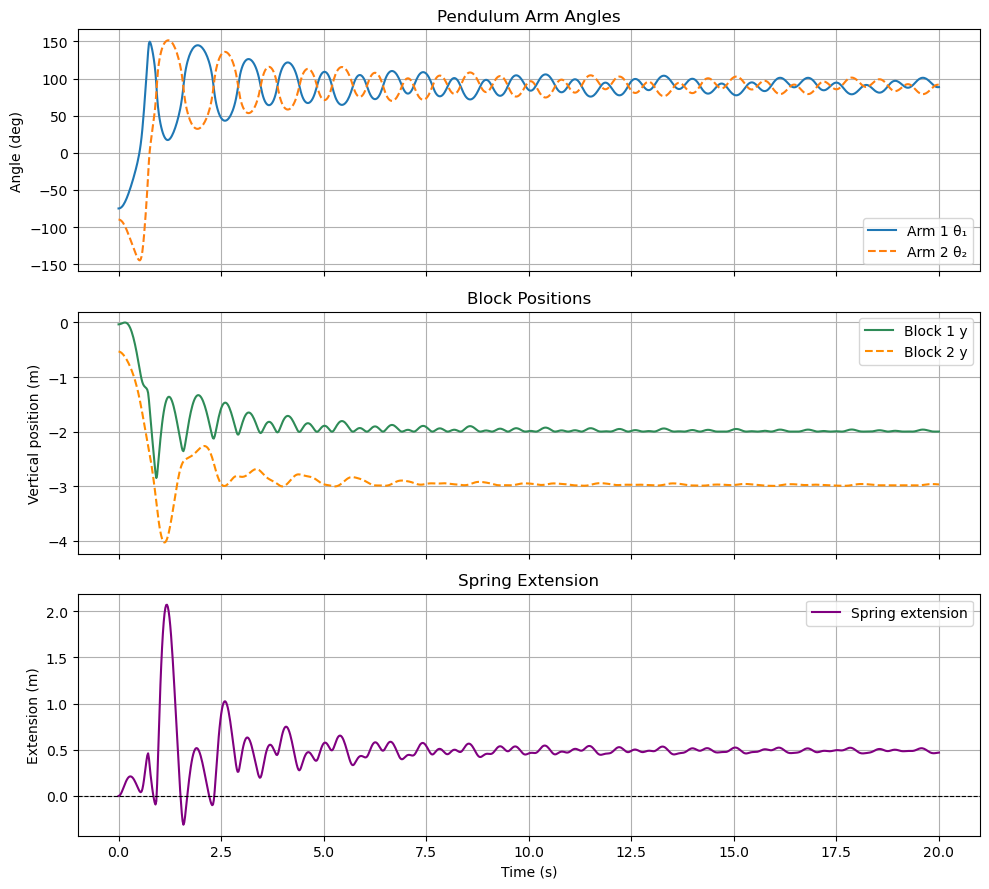

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(sol.t, np.rad2deg(sol.y[2]), label='Arm 1 θ₁')
axes[0].plot(sol.t, np.rad2deg(sol.y[5]), label='Arm 2 θ₂', ls='--')
axes[0].set_ylabel('Angle (deg)')
axes[0].legend(); axes[0].grid(True)
axes[0].set_title('Pendulum Arm Angles')

axes[1].plot(sol.t, sol.y[7], label='Block 1 y', color='seagreen')
axes[1].plot(sol.t, sol.y[9], label='Block 2 y', color='darkorange', ls='--')
axes[1].set_ylabel('Vertical position (m)')
axes[1].legend(); axes[1].grid(True)
axes[1].set_title('Block Positions')

spring_ext_vals = (sol.y[7] - sol.y[9]) - L0
axes[2].plot(sol.t, spring_ext_vals, color='purple', label='Spring extension')
axes[2].axhline(0, color='k', ls='--', lw=0.8)
axes[2].set_ylabel('Extension (m)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(); axes[2].grid(True)
axes[2].set_title('Spring Extension')

plt.tight_layout()
plt.show()

## Phase Portraits

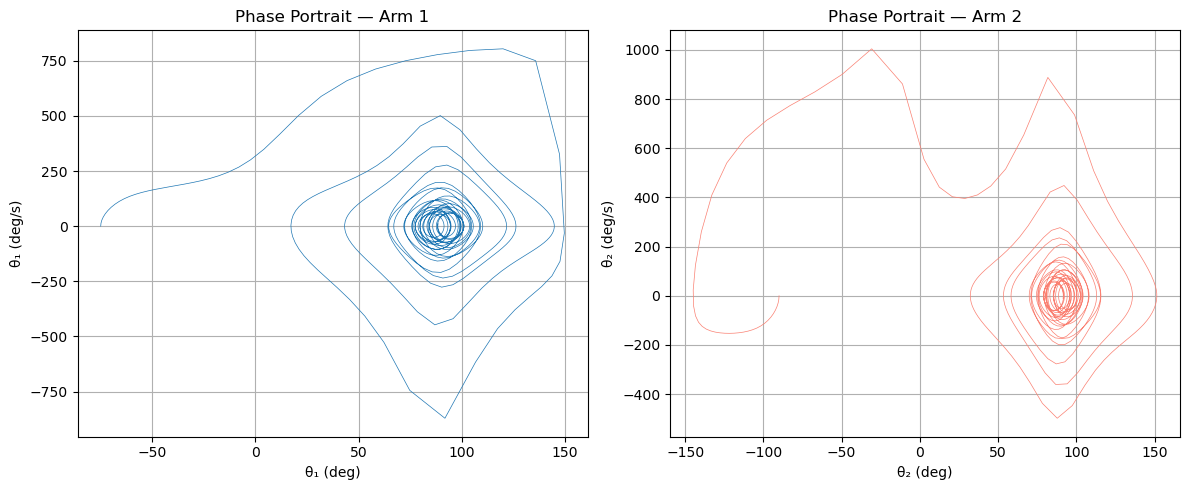

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(np.rad2deg(sol.y[2]), np.rad2deg(sol.y[12]), lw=0.5)
axes[0].set_xlabel('θ₁ (deg)'); axes[0].set_ylabel('θ̇₁ (deg/s)')
axes[0].set_title('Phase Portrait — Arm 1'); axes[0].grid(True)

axes[1].plot(np.rad2deg(sol.y[5]), np.rad2deg(sol.y[15]), lw=0.5, color='salmon')
axes[1].set_xlabel('θ₂ (deg)'); axes[1].set_ylabel('θ̇₂ (deg/s)')
axes[1].set_title('Phase Portrait — Arm 2'); axes[1].grid(True)

plt.tight_layout()
plt.show()